# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- **Use Pandas to load, inspect, and clean the dataset appropriately.**
- **Transform relevant columns to create measures that address the problem at hand.**
- conduct EDA: visualization and statistical measures to systematically understand the structure of the data
- recommend a set of airplanes and makes conforming to the client's request and identify at least *two* factors contributing to airplane safety. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.

### Make relevant library imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Loading and Inspection

### Load in data from the relevant directory and inspect the dataframe.
- inspect NaNs, datatypes, and summary statistics

In [8]:
# Loading data

df = pd.read_csv("AviationData.csv",encoding='latin-1')

df



C:\Users\Eng.Joe\AppData\Local\Temp\ipykernel_11084\2118472547.py:3: DtypeWarning: Columns (6,7,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("AviationData.csv",encoding='latin-1')


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88884,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,1.0,0.0,0.0,NaN,NaN,NaN,29-12-2022
88885,20221227106494,Accident,ERA23LA095,2022-12-26,"Hampton, NH",United States,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
88886,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,341525N,1112021W,PAN,PAYSON,...,Personal,NaN,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022
88887,20221227106498,Accident,WPR23LA076,2022-12-26,"Morgan, UT",United States,NaN,NaN,NaN,NaN,...,Personal,MC CESSNA 210N LLC,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


## Data Cleaning

### Filtering aircrafts and events

We want to filter the dataset to include aircraft that the client is interested in an analysis of:
- inspect relevant columns
- figure out any reasonable imputations
- filter the dataset

In [10]:
# inspecting relevant columns
# ── 1. Inspect relevant columns ───────────────────────────────────────────────
relevant_cols = ['Event.Date', 'Aircraft.Category', 'Amateur.Built', 'Make', 'Model']
print(df[relevant_cols].dtypes)

print("\n── Missing values ──")
print(df[relevant_cols].isna().sum())

print("\n── Aircraft.Category value counts ──")
print(df['Aircraft.Category'].value_counts(dropna=False))

print("\n── Amateur.Built value counts ──")
print(df['Amateur.Built'].value_counts(dropna=False))

Event.Date           object
Aircraft.Category    object
Amateur.Built        object
Make                 object
Model                object
dtype: object

── Missing values ──
Event.Date               0
Aircraft.Category    56602
Amateur.Built          102
Make                    63
Model                   92
dtype: int64

── Aircraft.Category value counts ──
Aircraft.Category
NaN                  56602
Airplane             27617
Helicopter            3440
Glider                 508
Balloon                231
Gyrocraft              173
Weight-Shift           161
Powered Parachute       91
Ultralight              30
Unknown                 14
WSFT                     9
Powered-Lift             5
Blimp                    4
UNK                      2
Rocket                   1
ULTR                     1
Name: count, dtype: int64

── Amateur.Built value counts ──
Amateur.Built
No     80312
Yes     8475
NaN      102
Name: count, dtype: int64


In [16]:
# ── 2. Imputations & reasoning ────────────────────────────────────────────────

# Convert Event.Date to datetime
df['Event.Date'] = pd.to_datetime(df['Event.Date'], errors='coerce')

# Aircraft.Category: NaNs are ambiguous — we cannot safely assume a category,
# so we keep only rows explicitly labelled 'Airplane'
# (drops helicopters, balloons, gliders, etc.)

# Amateur.Built: NaNs are ambiguous — we cannot confirm professional build,
# so we treat them conservatively and drop them.
# We keep only 'No' (i.e. professionally built aircraft).

print("\n   Rows before filtering:", len(df))
print("\n   Aircraft.Category nulls:", df['Aircraft.Category'].isna().sum())
print("   Amateur.Built nulls:", df['Amateur.Built'].isna().sum())


   Rows before filtering: 88889

   Aircraft.Category nulls: 56602
   Amateur.Built nulls: 102


In [18]:
# ── 3. Filtering Aviation datset ─────────────────────────────────────────────────────

# Filter 1: Date — client wants models potentially still active (1983 onwards)
df = df[df['Event.Date'].dt.year >= 1983]

# Filter 2: Airplanes only
df = df[df['Aircraft.Category'] == 'Airplane']

# Filter 3: Professionally built only
df = df[df['Amateur.Built'] == 'No']

print("Shape after filtering:", df.shape)
print("\n── Verify ──")
print(df['Aircraft.Category'].value_counts(dropna=False))
print(df['Amateur.Built'].value_counts(dropna=False))
print("Date range:", df['Event.Date'].min(), "→", df['Event.Date'].max())

Shape after filtering: (21447, 31)

── Verify ──
Aircraft.Category
Airplane    21447
Name: count, dtype: int64
Amateur.Built
No    21447
Name: count, dtype: int64
Date range: 1983-03-18 00:00:00 → 2022-12-26 00:00:00


### Cleaning and constructing Key Measurables

Injuries and robustness to destruction are a key interest point for the client. Clean and impute relevant columns and then create derived fields that best quantifies what the client wishes to track. **Use commenting or markdown to explain any cleaning assumptions as well as any derived columns you create.**

**Construct metric for fatal/serious injuries**

*Hint:* Estimate the total number of passengers on each flight. The likelihood of serious / fatal injury can be estimated as a fraction from this.

In [19]:
# ── 1. Available injury columns ─────────────────────────────────────────────────
injury_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 
               'Total.Minor.Injuries', 'Total.Uninjured']

print("── Dtypes ──")
print(df[injury_cols].dtypes)

print("\n── Missing values ──")
print(df[injury_cols].isna().sum())

print("\n── Summary statistics ──")
display(df[injury_cols].describe())

── Dtypes ──
Total.Fatal.Injuries      float64
Total.Serious.Injuries    float64
Total.Minor.Injuries      float64
Total.Uninjured           float64
dtype: object

── Missing values ──
Total.Fatal.Injuries      2750
Total.Serious.Injuries    2828
Total.Minor.Injuries      2544
Total.Uninjured            711
dtype: int64

── Summary statistics ──


,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured
count,18697.000000,18619.000000,18903.000000,20736.000000
mean,0.740868,0.323326,0.230598,7.718364
std,6.770638,2.378395,1.753088,35.633119
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000
75%,0.000000,0.000000,0.000000,2.000000
max,295.000000,161.000000,200.000000,588.000000


In [21]:
# ── 2. Cast to numeric & impute ───────────────────────────────────────────────

# Cast all injury columns to numeric 
for col in injury_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


df[injury_cols] = df[injury_cols].fillna(0)

print("── Missing values after imputation ──")
print(df[injury_cols].isna().sum())

── Missing values after imputation ──
Total.Fatal.Injuries      0
Total.Serious.Injuries    0
Total.Minor.Injuries      0
Total.Uninjured           0
dtype: int64


In [22]:
# ── 3. Derive total passengers & injury fraction ──────────────────────────────

# Total passengers = sum of all injury categories + uninjured
# This is our best estimate of how many people were on board
df['Total.Passengers'] = (df['Total.Fatal.Injuries'] +
                           df['Total.Serious.Injuries'] +
                           df['Total.Minor.Injuries'] +
                           df['Total.Uninjured'])

# Serious/fatal injury fraction:
# = (fatal + serious) / total passengers
# This is the core safety metric — what fraction of people on board
# suffered the worst outcomes in the event of an accident.
# Where Total.Passengers == 0 (no occupant data recorded), we assign NaN
# rather than 0 to avoid misleadingly "safe" entries influencing averages.
df['Injury.Fraction'] = np.where(
    df['Total.Passengers'] > 0,
    (df['Total.Fatal.Injuries'] + df['Total.Serious.Injuries']) / df['Total.Passengers'],
    np.nan
)

print("── Injury.Fraction summary ──")
print(df['Injury.Fraction'].describe())
print("\nNaNs (no occupant data):", df['Injury.Fraction'].isna().sum())

# Quick sanity check — fraction must be between 0 and 1
assert df['Injury.Fraction'].dropna().between(0, 1).all(), "Fraction out of [0,1] range!"
print("\n✓ All fractions within valid [0, 1] range")

── Injury.Fraction summary ──
count    20543.000000
mean         0.283971
std          0.431704
min          0.000000
25%          0.000000
50%          0.000000
75%          0.800000
max          1.000000
Name: Injury.Fraction, dtype: float64

NaNs (no occupant data): 904

✓ All fractions within valid [0, 1] range


**Aircraft.Damage**
- identify and execute any cleaning tasks
- construct a derived column tracking whether an aircraft was destroyed or not.

In [23]:
# ── 1. Inspect Aircraft.damage column ────────────────────────────────────────
print("── Dtype ──")
print(df['Aircraft.damage'].dtype)

print("\n── Missing values ──")
print(df['Aircraft.damage'].isna().sum())

print("\n── Value counts ──")
print(df['Aircraft.damage'].value_counts(dropna=False))

── Dtype ──
object

── Missing values ──
1227

── Value counts ──
Aircraft.damage
Substantial    16990
Destroyed       2316
NaN             1227
Minor            817
Unknown           97
Name: count, dtype: int64


In [24]:
# ── 2. Cleaning ───────────────────────────────────────────────────────────────

# Standardize to title case to fix any inconsistent capitalization
df['Aircraft.damage'] = df['Aircraft.damage'].str.strip().str.title()

# NaN assumption:
# Damage status is unknown for these rows — we cannot safely assume
# the aircraft was or wasn't destroyed, so we leave NaNs as-is.
# They will naturally be excluded when aggregating the is_destroyed metric.

print("── Value counts after cleaning ──")
print(df['Aircraft.damage'].value_counts(dropna=False))

── Value counts after cleaning ──
Aircraft.damage
Substantial    16990
Destroyed       2316
NaN             1227
Minor            817
Unknown           97
Name: count, dtype: int64


In [26]:
# ── 3. Derive is_destroyed column ─────────────────────────────────────────────

# Binary flag: 1 if the aircraft was destroyed, 0 if it sustained
# substantial/minor damage or none (i.e. survivable damage states).
# NaN where damage status was not recorded — excluded from averages,
# same reasoning as Injury.Fraction above.

df['is_destroyed'] = np.where(
    df['Aircraft.damage'] == 'Destroyed', 1,
    np.where(df['Aircraft.damage'].isna(), np.nan, 0)
)

print("── is_destroyed value counts ──")
print(df['is_destroyed'].value_counts(dropna=False))

print("\n── Destruction rate (overall) ──")
print(f"{df['is_destroyed'].mean():.2%} of accidents result in total destruction")

── is_destroyed value counts ──
is_destroyed
0.0    17904
1.0     2316
NaN     1227
Name: count, dtype: int64

── Destruction rate (overall) ──
11.45% of accidents result in total destruction


### Investigate the *Make* column
- Identify cleaning tasks here
- List cleaning tasks clearly in markdown
- Execute the cleaning tasks
- For your analysis, keep Makes with a reasonable number (you can put the threshold at 50 though lower could work as well)

In [27]:
# ── 1. Inspect Make column ────────────────────────────────────────────────────
print("── Dtype & Missing ──")
print(df['Make'].dtype)
print("Missing:", df['Make'].isna().sum())

print("\n── Total unique Makes (raw) ──")
print(df['Make'].nunique())

print("\n── Sample of raw Make values ──")
print(df['Make'].value_counts(dropna=False).head(30))

── Dtype & Missing ──
object
Missing: 3

── Total unique Makes (raw) ──
1332

── Sample of raw Make values ──
Make
CESSNA                      4867
PIPER                       2803
Cessna                      2279
Piper                       1186
BOEING                      1037
BEECH                       1018
Beech                        413
MOONEY                       238
Boeing                       227
CIRRUS DESIGN CORP           218
AIR TRACTOR INC              217
AIRBUS                       215
BELLANCA                     158
AERONCA                      149
MAULE                        144
Mooney                       125
EMBRAER                      123
Air Tractor                  117
LUSCOMBE                      95
CHAMPION                      91
DEHAVILLAND                   91
STINSON                       91
AIR TRACTOR                   89
CIRRUS                        80
NORTH AMERICAN                79
GRUMMAN                       77
DIAMOND AIRCRAFT IND INC   

In [28]:
# ── 2. Execute cleaning tasks ─────────────────────────────────────────────────

# Task 1 & 2: Strip whitespace and title case
df['Make'] = df['Make'].str.strip().str.title()

# Task 3: Drop NaN Makes — unusable without manufacturer info
df = df[df['Make'].notna()]

# Task 4: Consolidate known variants of the same manufacturer
make_replacements = {
    'Beech'             : 'Beechcraft',
    'Boeing Company'    : 'Boeing',
    'Airbus Industrie'  : 'Airbus',
    'Mcdonnell Douglas' : 'McDonnell Douglas',
    'Md'                : 'McDonnell Douglas',
    'Canadair'          : 'Bombardier',
    'De Havilland'      : 'De Havilland',
    'Dehavilland'       : 'De Havilland',
}
df['Make'] = df['Make'].replace(make_replacements)

print("── Unique Makes after cleaning ──")
print(df['Make'].nunique())

print("\n── Top 30 Makes after cleaning ──")
print(df['Make'].value_counts().head(30))

── Unique Makes after cleaning ──
1082

── Top 30 Makes after cleaning ──
Make
Cessna                       7146
Piper                        3989
Beechcraft                   1445
Boeing                       1273
Mooney                        363
Airbus                        285
Cirrus Design Corp            220
Air Tractor Inc               219
Bellanca                      219
Maule                         215
Air Tractor                   206
Aeronca                       200
De Havilland                  168
Champion                      158
Embraer                       153
Grumman                       147
Luscombe                      141
Cirrus                        137
Stinson                       129
McDonnell Douglas             108
North American                106
Taylorcraft                    93
Aero Commander                 90
Aviat Aircraft Inc             76
Socata                         75
Diamond Aircraft Ind Inc       74
Aviat                          70
Bom

In [29]:
# ── 3. Keep Makes with at least 50 accident records ──────────────────────────

# Threshold reasoning: fewer than 50 samples per make produces unstable
# averages for Injury.Fraction and is_destroyed — conclusions drawn from
# small groups would not be statistically robust.

make_counts = df['Make'].value_counts()
valid_makes = make_counts[make_counts >= 50].index
df = df[df['Make'].isin(valid_makes)]

print(f"── Makes retained (>= 50 records): {len(valid_makes)} ──")
print(f"── Rows retained: {df.shape[0]} ──")
print("\n── Retained Makes & counts ──")
print(make_counts[make_counts >= 50])

── Makes retained (>= 50 records): 35 ──
── Rows retained: 17971 ──

── Retained Makes & counts ──
Make
Cessna                            7146
Piper                             3989
Beechcraft                        1445
Boeing                            1273
Mooney                             363
Airbus                             285
Cirrus Design Corp                 220
Air Tractor Inc                    219
Bellanca                           219
Maule                              215
Air Tractor                        206
Aeronca                            200
De Havilland                       168
Champion                           158
Embraer                            153
Grumman                            147
Luscombe                           141
Cirrus                             137
Stinson                            129
McDonnell Douglas                  108
North American                     106
Taylorcraft                         93
Aero Commander                      90

### Inspect Model column
- Get rid of any NaNs.
- Inspect the column and counts for each model/make. Are model labels unique to each make?
- If not, create a derived column that is a unique identifier for a given plane type.

In [30]:
# ── 1. Inspect Model column ───────────────────────────────────────────────────
print("── Dtype & Missing ──")
print(df['Model'].dtype)
print("Missing:", df['Model'].isna().sum())

print("\n── Total unique Models (raw) ──")
print(df['Model'].nunique())

print("\n── Sample of raw Model values ──")
print(df['Model'].value_counts(dropna=False).head(20))

── Dtype & Missing ──
object
Missing: 13

── Total unique Models (raw) ──
2065

── Sample of raw Model values ──
Model
172          769
737          403
152          316
182          304
172S         276
PA28         273
172N         249
SR22         240
180          213
A36          182
172M         180
150          179
PA-18-150    175
PA-28-140    169
172P         143
140          117
172R         109
170B         107
PA-28-180    105
PA-28-161    102
Name: count, dtype: int64


In [33]:
# ── 2. Drop NaN Models ────────────────────────────────────────────────────────

# Without a model label we cannot make model-level recommendations
# to the client — drop these rows.
df = df[df['Model'].notna()]

# Clean model values for consistency
df['Model'] = df['Model'].str.strip().str.upper()

print("── Rows after dropping NaN Models ──")
print(df.shape[0])

── Rows after dropping NaN Models ──
17958


In [34]:
# ── 3. Check if model labels are unique to each Make ─────────────────────────

# Group by Model and count how many distinct Makes share that model label
model_make_counts = df.groupby('Model')['Make'].nunique()

print("── Models shared across more than one Make ──")
shared_models = model_make_counts[model_make_counts > 1]
print(f"Count: {len(shared_models)}")
print(shared_models.sort_values(ascending=False).head(20))

# Inspect a concrete example to confirm the problem
example_model = shared_models.index[0]
print(f"\n── Example: Model '{example_model}' appears under these Makes ──")
print(df[df['Model'] == example_model][['Make', 'Model']].value_counts())

── Models shared across more than one Make ──
Count: 106
Model
7GCBC          3
S2R            3
500            3
7AC            3
7EC            3
400            3
7GCAA          3
7ECA           3
8GCBC          3
8KCAB          3
DHC-8-402      2
DC-10          2
DHC8           2
G 164          2
DHC-8-202      2
DHC-8-102      2
DHC-8          2
DC-10-30       2
CL-600-2D24    2
CL600 2D24     2
Name: Make, dtype: int64

── Example: Model '100' appears under these Makes ──
Make            Model
Aero Commander  100      12
Beechcraft      100       2
Name: count, dtype: int64


In [35]:
# ── 4. Create unique Make_Model identifier ────────────────────────────────────

# Since model labels are NOT unique across makes (e.g. "100" appears under
# multiple manufacturers), we concatenate Make + Model to create a globally
# unique identifier for each aircraft type.
# This ensures comparisons are always within a single manufacturer's model.

df['Make_Model'] = df['Make'].str.strip().str.title() + ' ' + df['Model'].str.strip().str.upper()

print("── Sample Make_Model values ──")
print(df['Make_Model'].value_counts().head(20))

print(f"\n── Total unique Make_Model identifiers: {df['Make_Model'].nunique()} ──")

── Sample Make_Model values ──
Make_Model
Cessna 172                 769
Boeing 737                 403
Cessna 152                 316
Cessna 182                 304
Cessna 172S                276
Piper PA28                 273
Cessna 172N                249
Cessna 180                 213
Cessna 172M                180
Cessna 150                 179
Piper PA-18-150            175
Piper PA-28-140            169
Beechcraft A36             165
Cirrus Design Corp SR22    144
Cessna 172P                143
Cessna 140                 116
Cessna 172R                109
Cessna 170B                107
Piper PA-28-180            105
Piper PA-28-161            102
Name: count, dtype: int64

── Total unique Make_Model identifiers: 2172 ──


In [36]:
# ── 5. Sanity check ───────────────────────────────────────────────────────────

# Verify each Make_Model maps to exactly one Make
check = df.groupby('Make_Model')['Make'].nunique()
assert (check == 1).all(), "Some Make_Model entries span multiple Makes!"
print("✓ Every Make_Model identifier maps to exactly one Make")

✓ Every Make_Model identifier maps to exactly one Make


### Cleaning other columns
- there are other columns containing data that might be related to the outcome of an accident. We list a few here:
- Engine.Type
- Weather.Condition
- Number.of.Engines
- Purpose.of.flight
- Broad.phase.of.flight

Inspect and identify potential cleaning tasks in each of the above columns. Execute those cleaning tasks. 

**Note**: You do not necessarily need to impute or drop NaNs here.

In [37]:
# ── 1. Inspect all five columns at once ──────────────────────────────────────
cols = ['Engine.Type', 'Weather.Condition', 'Number.of.Engines',
        'Purpose.of.flight', 'Broad.phase.of.flight']

for col in cols:
    print(f"\n{'─'*50}")
    print(f"── {col} ──")
    print(f"Dtype: {df[col].dtype} | Missing: {df[col].isna().sum()}")
    print(df[col].value_counts(dropna=False))


──────────────────────────────────────────────────
── Engine.Type ──
Dtype: object | Missing: 3230
Engine.Type
Reciprocating      12847
NaN                 3230
Turbo Prop           932
Turbo Fan            741
Unknown              110
Turbo Jet             76
Geared Turbofan       12
Turbo Shaft            9
UNK                    1
Name: count, dtype: int64

──────────────────────────────────────────────────
── Weather.Condition ──
Dtype: object | Missing: 2439
Weather.Condition
VMC    14337
NaN     2439
IMC      913
Unk      189
UNK       80
Name: count, dtype: int64

──────────────────────────────────────────────────
── Number.of.Engines ──
Dtype: float64 | Missing: 2105
Number.of.Engines
1.0    13231
2.0     2523
NaN     2105
4.0       67
3.0       26
0.0        6
Name: count, dtype: int64

──────────────────────────────────────────────────
── Purpose.of.flight ──
Dtype: object | Missing: 3101
Purpose.of.flight
Personal                     9856
NaN                          3101
I

In [38]:
# ── 2. Engine.Type ────────────────────────────────────────────────────────────

# Issues identified:
# - Inconsistent casing and whitespace
# - 'UNK' should be treated as NaN (unknown, not a real engine type)

df['Engine.Type'] = df['Engine.Type'].str.strip().str.title()
df['Engine.Type'] = df['Engine.Type'].replace('Unk', np.nan)

print("── Engine.Type after cleaning ──")
print(df['Engine.Type'].value_counts(dropna=False))

── Engine.Type after cleaning ──
Engine.Type
Reciprocating      12847
NaN                 3231
Turbo Prop           932
Turbo Fan            741
Unknown              110
Turbo Jet             76
Geared Turbofan       12
Turbo Shaft            9
Name: count, dtype: int64


In [39]:
# ── 3. Weather.Condition ──────────────────────────────────────────────────────

# Issues identified:
# - Inconsistent casing and whitespace
# - 'UNK' should be treated as NaN (condition not recorded)
# - Valid categories are IMC (Instrument Meteorological Conditions)
#   and VMC (Visual Meteorological Conditions)

df['Weather.Condition'] = df['Weather.Condition'].str.strip().str.upper()
df['Weather.Condition'] = df['Weather.Condition'].replace('UNK', np.nan)

print("── Weather.Condition after cleaning ──")
print(df['Weather.Condition'].value_counts(dropna=False))

── Weather.Condition after cleaning ──
Weather.Condition
VMC    14337
NaN     2708
IMC      913
Name: count, dtype: int64


In [40]:
# ── 4. Number.of.Engines ─────────────────────────────────────────────────────

# Issues identified:
# - Stored as float due to NaNs — cast to nullable integer
# - Implausibly high values should be inspected
# - 0 engines is likely a data entry error — replace with NaN

df['Number.of.Engines'] = pd.to_numeric(df['Number.of.Engines'], errors='coerce')

# Inspect distribution before cleaning
print("── Number.of.Engines value counts (raw) ──")
print(df['Number.of.Engines'].value_counts(dropna=False).sort_index())

# 0 engines is not physically meaningful — treat as unknown
df['Number.of.Engines'] = df['Number.of.Engines'].replace(0, np.nan)

# Values above 4 are extremely rare for commercial aviation — inspect
print("\n── Engines > 4 ──")
print(df[df['Number.of.Engines'] > 4]['Number.of.Engines'].value_counts())

print("\n── Number.of.Engines after cleaning ──")
print(df['Number.of.Engines'].value_counts(dropna=False).sort_index())

── Number.of.Engines value counts (raw) ──
Number.of.Engines
0.0        6
1.0    13231
2.0     2523
3.0       26
4.0       67
NaN     2105
Name: count, dtype: int64

── Engines > 4 ──
Series([], Name: count, dtype: int64)

── Number.of.Engines after cleaning ──
Number.of.Engines
1.0    13231
2.0     2523
3.0       26
4.0       67
NaN     2111
Name: count, dtype: int64


In [41]:
# ── 5. Purpose.of.flight ─────────────────────────────────────────────────────

# Issues identified:
# - Inconsistent casing and whitespace
# - 'Unknown' and 'UNKNOWN' should be mapped to NaN
# - Some categories may be near-duplicates worth consolidating

df['Purpose.of.flight'] = df['Purpose.of.flight'].str.strip().str.title()
df['Purpose.of.flight'] = df['Purpose.of.flight'].replace(
    {'Unknown': np.nan, 'Unkn': np.nan}
)

print("── Purpose.of.flight after cleaning ──")
print(df['Purpose.of.flight'].value_counts(dropna=False))

── Purpose.of.flight after cleaning ──
Purpose.of.flight
Personal                     9856
NaN                          3409
Instructional                2410
Aerial Application            724
Business                      412
Positioning                   271
Skydiving                     157
Aerial Observation            147
Other Work Use                121
Banner Tow                     86
Flight Test                    73
Ferry                          72
Executive/Corporate            67
Glider Tow                     29
Public Aircraft - Federal      28
Public Aircraft                27
Public Aircraft - State        21
Air Race Show                  15
Firefighting                   13
Public Aircraft - Local        11
Pubs                            3
Air Race/Show                   2
Air Drop                        2
Asho                            2
Name: count, dtype: int64


In [42]:
# ── 6. Broad.phase.of.flight ─────────────────────────────────────────────────

# Issues identified:
# - Inconsistent casing and whitespace
# - 'Unknown' variants should be mapped to NaN
# - 'Standing' and 'Other' are vague but retained as valid categories

df['Broad.phase.of.flight'] = df['Broad.phase.of.flight'].str.strip().str.title()
df['Broad.phase.of.flight'] = df['Broad.phase.of.flight'].replace(
    {'Unknown': np.nan}
)

print("── Broad.phase.of.flight after cleaning ──")
print(df['Broad.phase.of.flight'].value_counts(dropna=False))

── Broad.phase.of.flight after cleaning ──
Broad.phase.of.flight
NaN            15505
Landing         1114
Takeoff          427
Cruise           240
Approach         210
Maneuvering      127
Taxi             101
Go-Around         81
Descent           62
Climb             53
Standing          36
Other              2
Name: count, dtype: int64


### Column Removal
- inspect the dataframe and drop any columns that have too many NaNs

In [43]:
# ── 1. Inspect NaN percentage across all columns ──────────────────────────────
nan_summary = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct':   (df.isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)

print("── NaN summary across all columns ──")
print(nan_summary)

── NaN summary across all columns ──
                        missing_count  missing_pct
Schedule                        15771        87.82
Broad.phase.of.flight           15505        86.34
Air.carrier                      9456        52.66
Airport.Code                     6270        34.91
Airport.Name                     6164        34.32
Report.Status                    3807        21.20
Purpose.of.flight                3409        18.98
Engine.Type                      3231        17.99
Weather.Condition                2708        15.08
Number.of.Engines                2111        11.76
Longitude                        1922        10.70
Latitude                         1919        10.69
Aircraft.damage                  1093         6.09
is_destroyed                     1093         6.09
Publication.Date                  798         4.44
Injury.Fraction                   791         4.40
Injury.Severity                   728         4.05
FAR.Description                   349        

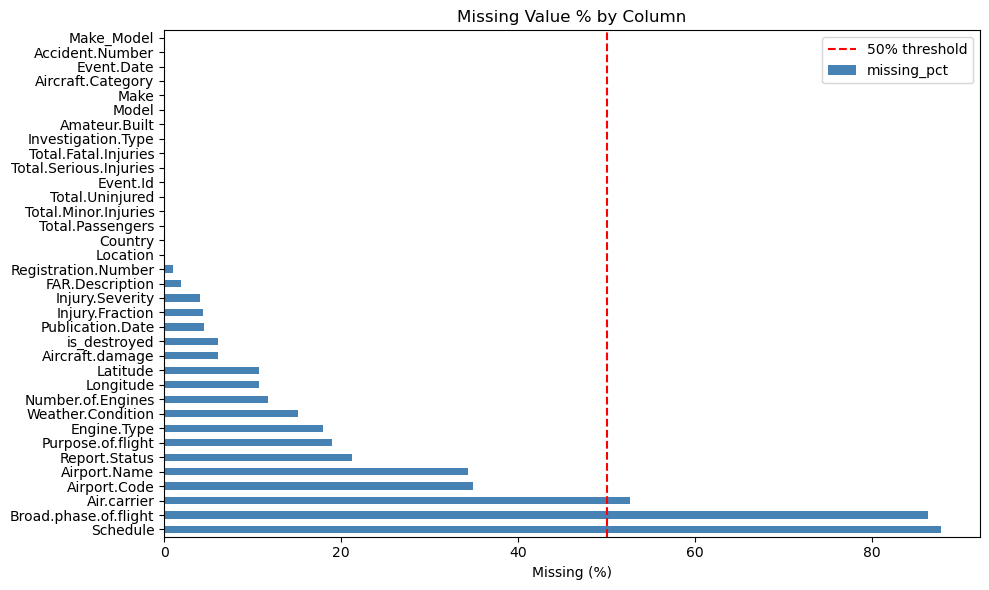

In [46]:
# ── 2. Visualise missingness ──────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
nan_summary['missing_pct'].plot(kind='barh', color='steelblue')
plt.axvline(x=50, color='red', linestyle='--', label='50% threshold')
plt.xlabel('Missing (%)')
plt.title('Missing Value % by Column')
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
# ── 3. Drop columns exceeding 50% missing ────────────────────────────────────

# Threshold: 50% — columns missing more than half their values
# provide too little signal to be analytically useful and
# risk introducing bias if imputed at scale.

threshold = 50
cols_to_drop = nan_summary[nan_summary['missing_pct'] > threshold].index.tolist()

print(f"── Columns to drop (> {threshold}% missing) ──")
for col in cols_to_drop:
    pct = nan_summary.loc[col, 'missing_pct']
    print(f"  {col}: {pct}% missing")

df = df.drop(columns=cols_to_drop)

print(f"\n── Shape after column removal: {df.shape} ──")

── Columns to drop (> 50% missing) ──
  Schedule: 87.82% missing
  Broad.phase.of.flight: 86.34% missing
  Air.carrier: 52.66% missing

── Shape after column removal: (17958, 32) ──


In [48]:
# ── 4. Final column overview ──────────────────────────────────────────────────
print("── Remaining columns & missing % ──")
remaining = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct':   (df.isna().mean() * 100).round(2)
}).sort_values('missing_pct', ascending=False)

print(remaining)

── Remaining columns & missing % ──
                        missing_count  missing_pct
Airport.Code                     6270        34.91
Airport.Name                     6164        34.32
Report.Status                    3807        21.20
Purpose.of.flight                3409        18.98
Engine.Type                      3231        17.99
Weather.Condition                2708        15.08
Number.of.Engines                2111        11.76
Longitude                        1922        10.70
Latitude                         1919        10.69
is_destroyed                     1093         6.09
Aircraft.damage                  1093         6.09
Publication.Date                  798         4.44
Injury.Fraction                   791         4.40
Injury.Severity                   728         4.05
FAR.Description                   349         1.94
Registration.Number               169         0.94
Location                            4         0.02
Country                             1         

### Save DataFrame to csv
- its generally useful to save data to file/server after its in a sufficiently cleaned or intermediate state
- the data can then be loaded directly in another notebook for further analysis
- this helps keep your notebooks and workflow readable, clean and modularized

In [49]:
# ── Save cleaned DataFrame to CSV ─────────────────────────────────────────────

# Saving the cleaned data as a separate file keeps the cleaning and analysis
# notebooks independent — the analysis notebook can load this directly
# without re-running all cleaning steps.

df.to_csv('aviation_cleaned.csv', index=False)

# ── Verify the save ───────────────────────────────────────────────────────────
df_check = pd.read_csv('aviation_cleaned.csv', low_memory=False)

print(f"── Saved shape:   {df.shape} ──")
print(f"── Reloaded shape: {df_check.shape} ──")
assert df.shape == df_check.shape, "Shape mismatch — save may be corrupted!"
print("\n✓ File saved and verified successfully as 'aviation_cleaned.csv'")

print("\n── Columns saved ──")
print(df_check.columns.tolist())

── Saved shape:   (17958, 32) ──
── Reloaded shape: (17958, 32) ──

✓ File saved and verified successfully as 'aviation_cleaned.csv'

── Columns saved ──
['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date', 'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code', 'Airport.Name', 'Injury.Severity', 'Aircraft.damage', 'Aircraft.Category', 'Registration.Number', 'Make', 'Model', 'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description', 'Purpose.of.flight', 'Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition', 'Report.Status', 'Publication.Date', 'Total.Passengers', 'Injury.Fraction', 'is_destroyed', 'Make_Model']
